# 项目：分析鸢尾花种类数据

## 分析目标

此数据分析报告的目的是基于鸢尾花的属性数据，分析两种鸢尾花萼片、花瓣的长度和宽度平均值，是否存在显著性差异，让我们可以对不同种类鸢尾花的属性特征进行推断。

## 简介

原始数据`Iris.csv`包括两种鸢尾花，每种有 50 个样本，以及每个样本的一些属性，包括萼片的长度和宽度、花瓣的长度和宽度。

`Iris.csv`每列的含义如下：
- Id：样本的ID。
- SepalLengthCm：萼片的长度（单位为厘米）。
- SepalWidthCm：萼片的宽度（单位为厘米）。
- PetalLengthCm：花瓣的长度（单位为厘米）。
- PetalWidthCm：花瓣的宽度（单位为厘米）。
- Species：鸢尾花种类。

## 读取数据

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
original_data = pd.read_csv('iris.csv')

In [41]:
original_data.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [42]:
cleaned_data = original_data.copy()

## 评估数据

### 数据整齐度

In [43]:
cleaned_data.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


可以看出数据的整齐度没有问题，数据每个变量都对应着一列，每个id都对应一行


### 数据格式干净度

In [44]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             100 non-null    int64  
 1   SepalLengthCm  100 non-null    float64
 2   SepalWidthCm   100 non-null    float64
 3   PetalLengthCm  100 non-null    float64
 4   PetalWidthCm   100 non-null    float64
 5   Species        100 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 4.8+ KB


`species`应该修改为分类数据，不是字符串数据;`id`是字符串str数据不是整数int64数据；表中各数据都为100说明没有缺失数据

### 处理数据格式

In [45]:
cleaned_data['Species'] = cleaned_data['Species'].astype('category')
cleaned_data['Id'] = cleaned_data['Id'].astype('str')

In [46]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             100 non-null    object  
 1   SepalLengthCm  100 non-null    float64 
 2   SepalWidthCm   100 non-null    float64 
 3   PetalLengthCm  100 non-null    float64 
 4   PetalWidthCm   100 non-null    float64 
 5   Species        100 non-null    category
dtypes: category(1), float64(4), object(1)
memory usage: 4.3+ KB


#### 处理缺失数据

本数据库并未发现缺失数据，因此无需处理

#### 处理重复数据

本数据只有`id`数据不能出现重复

In [47]:
cleaned_data['Id'].duplicated().sum()

np.int64(0)

未发现`Id`列中有重复值

#### 处理不一致数据

不一致数据可能存在于`Species`变量中，我们要查看是否存在多个不同值指代同一鸢尾花种类的情况。

In [48]:
cleaned_data['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Name: count, dtype: int64

结果看出不一致数据只有两种，因此不存在不一致数据

#### 处理无效或错误数据

可以通过DataFrame的`describe`方法，对数值统计信息进行快速了解。

In [49]:
cleaned_data.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,100.000000,100.000000,100.000000,100.000000
mean,5.471000,3.094000,2.862000,0.785000
std,0.641698,0.476057,1.448565,0.566288
min,4.300000,2.000000,1.000000,0.100000
25%,5.000000,2.800000,1.500000,0.200000
50%,5.400000,3.050000,2.450000,0.800000
75%,5.900000,3.400000,4.325000,1.300000
max,7.000000,4.400000,5.100000,1.800000


可以看出表中不存在极端大/小的异常值，可以判定为无错误数据

## 整理数据

对数据的整理，与分析方向紧密相关。此次数据分析目标是，基于鸢尾花的属性数据，分析两种鸢尾花萼片、花瓣的长度和宽度平均值，是否存在显著性差异。

那么我们可以对数据基于`Species`列，先把各个鸢尾花种类样本数据筛选出来。

In [50]:
#布尔索引法 支持复杂运算、numpy 数组，兼容全部 pandas 操作
Iris_setosa = cleaned_data[cleaned_data['Species'] == 'Iris-setosa']   
Iris_setosa.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [51]:
len(Iris_setosa)

50

In [52]:
#query()法 部分复杂 pandas 对象无法在 query 字符串里使用
Iris_versicolor = cleaned_data.query("Species == 'Iris-versicolor'") 
Iris_versicolor.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
50,51,7.0,3.2,4.7,1.4,Iris-versicolor
51,52,6.4,3.2,4.5,1.5,Iris-versicolor
52,53,6.9,3.1,4.9,1.5,Iris-versicolor
53,54,5.5,2.3,4.0,1.3,Iris-versicolor
54,55,6.5,2.8,4.6,1.5,Iris-versicolor
55,56,5.7,2.8,4.5,1.3,Iris-versicolor
56,57,6.3,3.3,4.7,1.6,Iris-versicolor
57,58,4.9,2.4,3.3,1.0,Iris-versicolor
58,59,6.6,2.9,4.6,1.3,Iris-versicolor
59,60,5.2,2.7,3.9,1.4,Iris-versicolor


In [53]:
len(Iris_versicolor)

50

## 探索数据

在着手推断统计学分析之前，我们可以先借助数据可视化，探索`Setosa`和`Versicolor`这两种鸢尾花的变量特点。

可视化探索可以帮我们对数据有一个更直观的理解，比如了解数据的分布、发现变量之间的关系，等等，从而为后续的进一步分析提供方向。

针对数值，我们可以直接绘制成对图，利用其中的密度图查看不同变量的分布，以及利用散点图了解变量之间的关系。

并且，由于此次分析目的是了解不同种类鸢尾花的属性特征是否存在差异，我们可以利用颜色对图表上不种类类的样本进行分类。

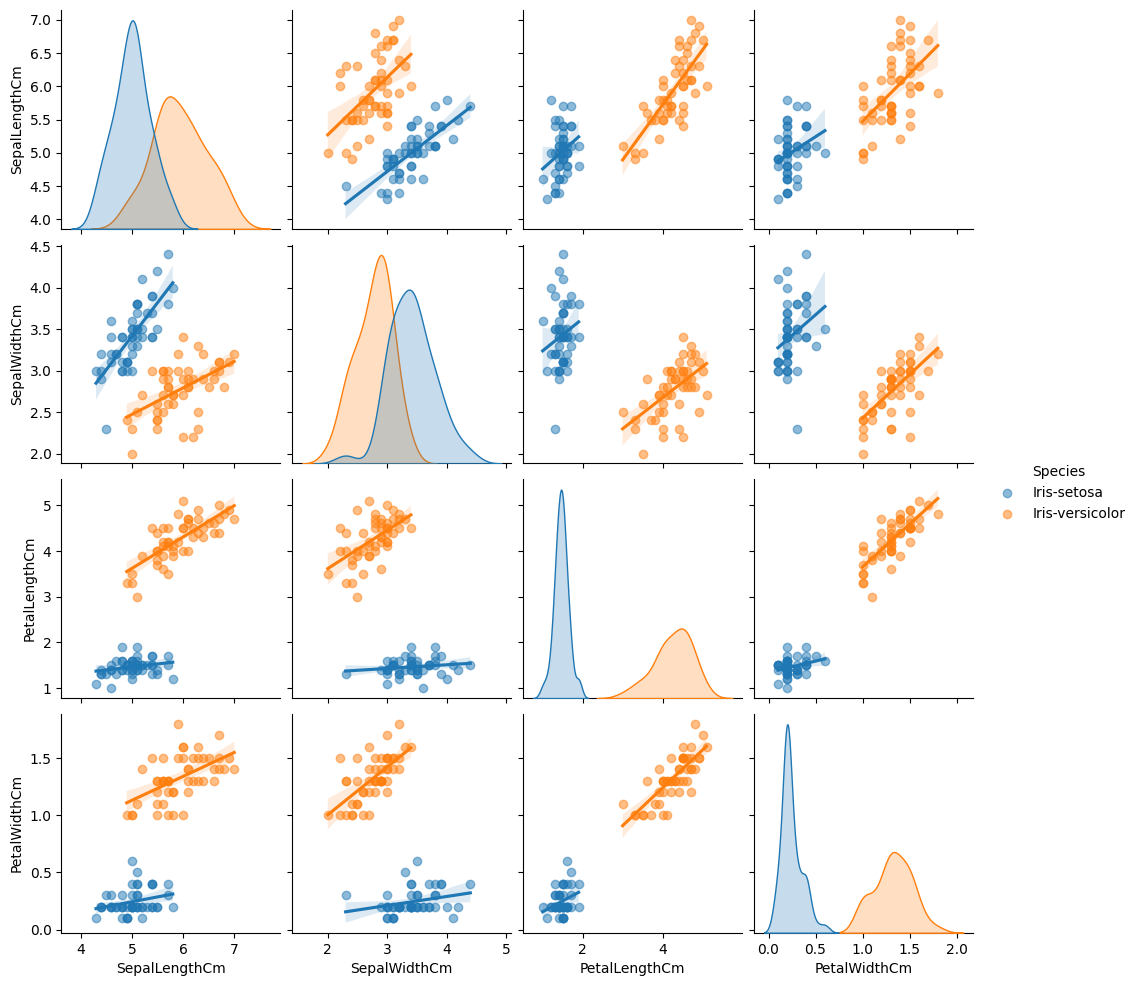

In [54]:
sns.pairplot(data=cleaned_data,
             hue='Species',
             kind = 'reg',
             plot_kws={'scatter_kws':{'alpha':0.5}})

从以上可以看出，`Setosa`和`Versicolor`样本的花瓣长度以及花瓣宽度的分布存在明显数值上的不同，已经可以猜测假设检验的结果是，两种鸢尾花的花瓣长度与宽度有统计显著性差异。

萼片的长度和宽度在分布上存在重叠，暂时无法仅通过图表下结论，需要进行假设检验，来推断总体的萼片长度和宽度之间是否有差异。

## 分析数据

利用假设检验对两种花的叶片长度宽度进行检验，是否存在显著差异
由于样本各有50，样本量较小，且分布为正态分布，因此采用t检验

In [66]:
from scipy.stats import ttest_ind

### 分析萼片长度

setosa和versicolor的萼片长度分布如下

<Axes: xlabel='SepalLengthCm', ylabel='Count'>

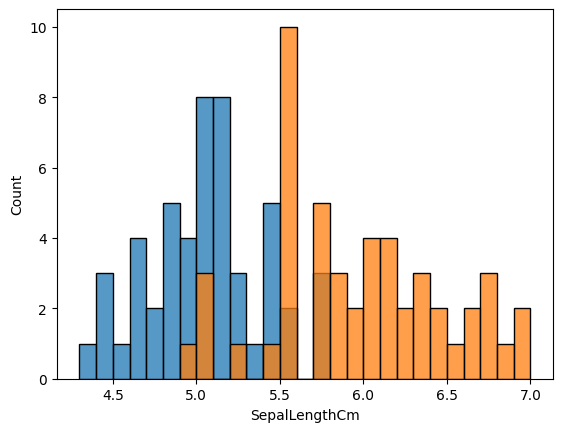

In [67]:
sns.histplot(Iris_setosa['SepalLengthCm'],binwidth=0.1)
sns.histplot(Iris_versicolor['SepalLengthCm'],binwidth=0.1)

### 建立假设

原假设$H_0$：setosa和versicolor的萼片长度平均值不存在显著区别

备择假设$H_1$：setosa和versicolor的萼片长度平均值存在显著区别

双尾检测

In [68]:
ttest_stat,p_value = ttest_ind(Iris_setosa['SepalLengthCm'],Iris_versicolor['SepalLengthCm'],alternative='two-sided')
print(f't统计量:{ttest_stat:.4f}, p值:{p_value:.4f}')


t统计量:-10.5210, p值:0.0000


显著性水平为0.05

In [69]:
if p_value < 0.05:
    print("拒绝原假设，两个样本均值存在显著差异")
else:
    print("接受原假设，两个样本均值不存在显著差异")

拒绝原假设，两个样本均值存在显著差异


### 分析萼片宽度

setosa和versicolor的萼片长度分布如下

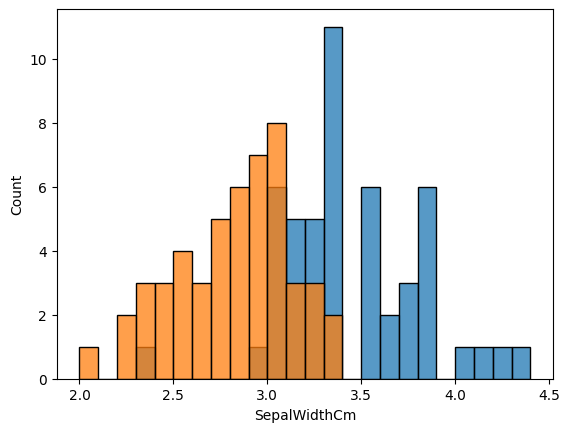

In [72]:
sns.histplot(Iris_setosa['SepalWidthCm'], binwidth = 0.1)
sns.histplot(Iris_versicolor['SepalWidthCm'], binwidth = 0.1)
plt.show()

### 建立假设

原假设$H_0$：setosa和versicolor的萼片宽度平均值不存在显著区别

备择假设$H_1$：setosa和versicolor的萼片宽度平均值存在显著区别

采用显著性水平0.05的双尾检验

In [74]:
ttest_stat2,p_value2 = ttest_ind(Iris_setosa['SepalWidthCm'],Iris_versicolor['SepalWidthCm'],alternative = 'two-sided')
print(f't统计量:{ttest_stat2:.4f}, p值:{p_value2:.4f}')

t统计量:9.2828, p值:0.0000


In [75]:
if p_value < 0.05:
    print("拒绝原假设，两个样本均值存在显著差异")
else:
    print("接受原假设，两个样本均值不存在显著差异")


拒绝原假设，两个样本均值存在显著差异


# 结论

通过理论统计学的计算过程，我们发现，Setosa 鸢尾花和 versicolor 鸢尾花萼片、花瓣的长度和宽度平均值，均存在统计学显著性的差异。